# Projekat: Segmentacija Zdravstvenih Profila Korišćenjem Nenadgledanog Učenja

# PRELIMINARNI SADRŽAJ RADA

1.  **Uvod i Teorijski okvir**
      * 1.1. Motivacija i Problem
      * 1.2. Šta je nenadgledano učenje
      * 1.3. Teorijska osnova algoritama za klasterizaciju
2.  **Metodologija: Priprema i Inženjering Podataka**
      * 2.1. Opis skupa podataka "Sleep Health and Lifestyle"
      * 2.2. Čišćenje podataka: Tretman nedostajućih vrednosti i šuma
      * 2.3. Inženjering obeležja (Feature Engineering): Dekonstrukcija složenih varijabli
      * 2.4. Transformacija kategoričkih podataka: One-Hot Encoding
3.  **Statistička Analiza i Priprema za Modelovanje** (Ovo radimo u sledećem chatu)
      * 3.1. Eksplorativna analiza (EDA)
      * 3.2. Skaliranje podataka i Standardizacija
      * 3.3. Redukcija dimenzionalnosti (PCA)
4.  **Implementacija Modela Klasterizacije**
      * 4.1. Optimizacija parametara za K-Means
      * 4.2. Detekcija šuma pomoću DBSCAN-a
      * 4.3. Hijerarhijska analiza
5.  **Diskusija i Profilisanje Klastera**
6.  **Zaključak**

-----

# 1.Uvod: Otkrivanje nevidljivih obrazaca u zdravlju sna




---



##1.1. Motivacija i Problem
San nije samo pasivno stanje odmora; to je složen fiziološki proces ključan za kognitivne funkcije, emocionalnu stabilnost i fizičko zdravlje. U modernom društvu, poremećaji sna poput insomnije i apneje postaju epidemija. Tradicionalna medicina često posmatra pacijente kroz unapred definisane dijagnoze. Međutim, šta ako postoje podtipovi pacijenata koje još nismo definisali?

Ovde na scenu stupa **Mašinsko učenje**, specifično **Nenadgledano učenje (Unsupervised Learning)**.

##1.2. Nenadgledano učenje: Istraživač u nepoznatom
Zamisli da si arheolog koji je upravo iskopao hiljade drevnih novčića iz različitih civilizacija. Nemaš knjigu koja ti kaže "ovo je rimski, ovo je grčki". Tvoj zadatak je da ih sortiraš. Gledaš ih i kažeš: "Ovi su veliki i zlatni, idu na jednu gomilu. Ovi su mali i bakarni, idu na drugu."

To je suština nenadgledanog učenja. Mi algoritmu ne dajemo tačne odgovore (labele). Mi mu dajemo podatke o pacijentima (godine, pritisak, broj koraka) i kažemo: **"Pronađi mi prirodne grupe (klastere) ljudi koji su međusobno slični, a različiti od drugih."**

U ovom radu, naš cilj nije da predvidimo ko ima poremećaj sna (to bi bila klasifikacija), već da *otkrijemo profile ljudi* na osnovu njihovog životnog stila i zdravlja.


##1.3. Teorijska osnova algoritama za klasterizaciju

U ovom radu koristićemo tri fundamentalno različita pristupa klasterizaciji kako bismo osigurali robustnost naših zaključaka. Svaki od njih "gleda" podatke na drugačiji način.

### A) K-Means (Algoritam centroida)
**Analogija:** Zamisli da želiš da otvoriš 3 picerije u gradu tako da pokriješ sve stanovnike. Gde ćeš ih postaviti? K-Means radi upravo to.
1.  Nasumično "baci" K tačaka (centara budućih picerija) na mapu.
2.  Svaki stanovnik (podatak) se prijavljuje onoj piceriji koja mu je najbliža.
3.  Vlasnik picerije gleda gde su njegovi kupci i pomera radnju tačno u geografski centar te grupe.
4.  Ovaj proces se ponavlja dok se picerije ne prestanu pomerati.

**Matematička suština:** K-Means pokušava da minimizuje **inerciju** (WCSS - Within-Cluster Sum of Squares). To je zbir kvadrata udaljenosti svake tačke od njenog centra.
* *Mane:* Moramo unapred reći koliko picerija (klastera) želimo. Takođe, ovaj algoritam voli "okrugle" klastere i ne snalazi se dobro sa podacima čudnih oblika.

### B) DBSCAN (Algoritam gustine)
**Analogija:** Zamisli arhipelag ostrva u okeanu.
DBSCAN ne traži centre. On posmatra **gustinu**. On ide od čoveka do čoveka. Ako stojiš blizu mnogo drugih ljudi, ti si deo kopna (klastera). Ako hodaš i dalje ima ljudi oko tebe, klaster se širi.
Ako si sam na sred okeana, daleko od svih, DBSCAN te označava kao **Šum (Outlier)** ili brodolomnika.

**Zašto je ovo važno za nas?** U medicinskim podacima često imamo anomalije – ljude sa ekstremno čudnim parametrima. K-Means bi na silu pokušao da ih ubaci u neku grupu, što bi pokvarilo prosek. DBSCAN će ih prepoznati kao anomalije i isključiti iz analize, što nam daje čistije profile.

### C) Aglomerativno Hijerarhijsko Klasterisanje
**Analogija:** Porodično stablo.
Ovaj algoritam kreće od pretpostavke da je svaka osoba (tačka) svoj sopstveni klaster. Zatim traži dve najsličnije osobe i spaja ih u par. Onda traži najsličniji par i spaja ga sa trećom osobom, i tako dalje, sve dok se svi ne spoje u jednu veliku grupu.

**Moć ovog pristupa:** Mi kao istraživači možemo da "presečemo" to stablo na bilo kojoj visini. Ako presečemo nisko, dobićemo mnogo malih, specifičnih grupa. Ako presečemo visoko, dobićemo par generalnih grupa. Ovo nam daje fleksibilnost u odlučivanju koliko detaljno želimo da segmentiramo pacijente.

---


# **2: Metodologija – Od sirovih podataka do informacija**

U ovom delu prelazimo sa teorije na praksu. Podaci u sirovom obliku su retko spremni za mašinsko učenje. Moramo ih "pročistiti" i prevesti na jezik koji algoritam razume.

## 2.1. Učitavanje i Inicijalna Inspekcija
Prvi korak u svakom Data Science projektu je razumevanje materijala sa kojim radimo. Koristimo biblioteku pandas za manipulaciju podacima.

Kod (Učitavanje biblioteka i podataka):

In [ ]:
# Importovanje neophodnih biblioteka za analizu i vizuelizaciju
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteke za mašinsko učenje (Scikit-Learn)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Biblioteke za upravljanje sistemom i podacima
import warnings
import kagglehub
import os

In [ ]:
# Ignorisanje nepotrebnih upozorenja radi preglednosti ispisa
warnings.filterwarnings('ignore')

# --- PREUZIMANJE I UČITAVANJE PODATAKA ---

# Preuzimanje najnovije verzije skupa podataka sa Kaggle repozitorijuma
print("Preuzimanje podataka...")
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
print("Putanja do preuzetih fajlova:", path)

# Definisanje pune putanje do CSV fajla
csv_file = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")

# Učitavanje podataka u Pandas DataFrame
df = pd.read_csv(csv_file)

# --- INICIJALNI PREGLED ---

# Prikaz prvih 5 redova da bismo stekli uvid u strukturu atributa
print("\nPrvih 5 redova skupa podataka:")
display(df.head())

# Provera tipova podataka, dimenzija i nedostajućih vrednosti
print("\nStruktura i informacije o skupu podataka:")
df.info()

Preuzimanje podataka...
Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Putanja do preuzetih fajlova: /kaggle/input/sleep-health-and-lifestyle-dataset

Prvih 5 redova skupa podataka:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Struktura i informacije o skupu podataka:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
me

## 2.2. Čišćenje podataka: Tretman nedostajućih vrednosti
U realnom svetu, podaci su "prljavi". Nedostajuće vrednosti (NaN - Not a Number) su čest problem. Većina algoritama za klasterizaciju (kao K-Means) ne može da radi sa praznim poljima – to je kao da pokušavate da izračunate prosečnu ocenu studenta koji nije izašao na ispit.

U našem skupu podataka, primećujemo specifičnost u koloni Sleep Disorder. Mnogi redovi su prazni.

Pogrešan pristup: Obrisati te redove. To bi značilo brisanje zdravih ljudi iz studije!

Ispravan pristup: Razumeti kontekst. U medicinskom kartonu, ako polje "Poremećaj" nije popunjeno, to obično znači "Nema poremećaja".

Takođe, kolona Person ID je samo administrativni broj. Da li to što je neko "Pacijent broj 5" utiče na njegov krvni pritisak? Ne. Zato tu kolonu uklanjamo da ne bi zbunjivala model (da model ne bi greškom našao vezu između rednog broja i zdravlja).

Kod (Čišćenje):

In [ ]:
# 1. Uklanjanje irelevantne kolone 'Person ID'
# axis=1 označava da brišemo kolonu, a ne red
df = df.drop('Person ID', axis=1)

# 2. Tretman nedostajućih vrednosti u 'Sleep Disorder'
# Provera pre izmene
print("Broj nedostajućih vrednosti pre popunjavanja:")
print(df['Sleep Disorder'].isna().sum())

# Popunjavanje NaN vrednosti stringom 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Provera nakon izmene
print("\nDistribucija kategorija nakon čišćenja:")
print(df['Sleep Disorder'].value_counts())

Broj nedostajućih vrednosti pre popunjavanja:
219

Distribucija kategorija nakon čišćenja:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


##2.3. Inženjering obeležja (Feature Engineering)
Inženjering obeležja je umetnost pretvaranja sirovih podataka u format koji bolje opisuje problem. Pogledajmo kolonu Blood Pressure (Krvni pritisak). Ona sadrži vrednosti poput "126/83". Za računar, ovo je samo tekst (string). On ne zna da je 126 sistolni ("gornji"), a 83 dijastolni ("donji") pritisak, niti da su ta dva broja povezana, ali različita.

Ako bismo ovo ostavili kao tekst, model ne bi mogao da koristi tu informaciju. Zato ćemo "hirurški" razdvojiti ovu kolonu na dve nove, numeričke varijable. Ovo drastično povećava informativnu moć našeg modela.

Razdvajanje krvnog pritiska:

In [ ]:
# Razdvajanje kolone 'Blood Pressure' na dve nove kolone
# Metoda split deli string na mestu gde je '/'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Konvertovanje novih kolona iz stringa u brojeve (integer)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])

# Uklanjanje originalne tekstualne kolone
df = df.drop('Blood Pressure', axis=1)

# Prikaz rezultata
print("Prvih 5 redova sa novim kolonama za pritisak:")
display(df[['Systolic_BP', 'Diastolic_BP']].head())

Prvih 5 redova sa novim kolonama za pritisak:


,Systolic_BP,Diastolic_BP
0,126,83
1,125,80
2,125,80
3,140,90
4,140,90


##2.4. Transformacija kategoričkih podataka: One-Hot Encoding
Mašinsko učenje je bazirano na matematičkim jednačinama. Kako u jednačinu ubaciti reč "Nurse" (Medicinska sestra) ili "Engineer" (Inženjer)? Moramo ih pretvoriti u brojeve.

Postoje dva načina, ali jedan je opasan za klasterizaciju:

Label Encoding (Pogrešno za ovaj slučaj): Dodeliti brojeve: Inženjer=1, Doktor=2, Sestra=3.

Problem: Algoritam će misliti da je Sestra (3) "veća" ili "vrednija" od Inženjera (1), ili da je prosečna vrednost između Inženjera i Sestre zapravo Doktor (1+3 / 2 = 2). To nema smisla!

One-Hot Encoding (Ispravno): Pravimo nove kolone za svako zanimanje. Kolona Occupation_Nurse će imati vrednost 1 ako je osoba sestra, a 0 ako nije. Ovo se zove "binarna reprezentacija". Time uklanjamo lažni matematički redosled između profesija.

Napomena: Kolonu Sleep Disorder nećemo koristiti za treniranje modela. Zašto? Zato što je to "odgovor" koji želimo da naš model sam otkrije (ili nešto slično tome). Sačuvaćemo je sa strane samo da bismo na kraju proverili koliko je naš model bio pametan (Validacija).

Kod (Encoding):

In [ ]:
# Izdvajanje 'Sleep Disorder' za kasniju validaciju (Ground Truth)
sleep_disorder_labels = df['Sleep Disorder'].copy()

# Uklanjanje target kolone iz seta za treniranje
df_for_clustering = df.drop('Sleep Disorder', axis=1)

# Identifikacija kategoričkih kolona
categorical_cols = ['Gender', 'Occupation', 'BMI Category']

# Primena One-Hot Encoding-a
# drop_first=True se koristi da bi se izbegla multikolinearnost (npr. ako nije Muško, mora biti Žensko)
df_encoded = pd.get_dummies(df_for_clustering, columns=categorical_cols, drop_first=True)

# Prikaz dimenzija novog skupa podataka
print(f"Dimenzije originalnog skupa: {df.shape}")
print(f"Dimenzije enkodiranog skupa: {df_encoded.shape}")
display(df_encoded.head())

Dimenzije originalnog skupa: (374, 13)
Dimenzije enkodiranog skupa: (374, 23)


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Gender_Male,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,126,83,True,...,False,False,False,False,False,True,False,False,False,True
1,28,6.2,6,60,8,75,10000,125,80,True,...,False,False,False,False,False,False,False,False,False,False
2,28,6.2,6,60,8,75,10000,125,80,True,...,False,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,140,90,True,...,False,False,True,False,False,False,False,False,True,False
4,28,5.9,4,30,8,85,3000,140,90,True,...,False,False,True,False,False,False,False,False,True,False


# 3. Statistička Analiza i Priprema za Modelovanje


##3.1. Eksplorativna Analiza Podataka (EDA)
Pre nego što skaliramo podatke, neophodno je vizuelno potvrditi distribuciju ključnih numeričkih obeležja. Klasterizacija se bazira na udaljenosti tačaka, a oblik distribucije (normalna, bimodalna, asimetrična) utiče na izbor algoritama i interpretaciju rezultata.

Na primer, bimodalna distribucija dužine sna (Sleep Duration) već nam sugeriše da prirodno postoje najmanje dve grupe ljudi sa različitim obrascima spavanja.

Vizuelizacija ključnih distribucija:

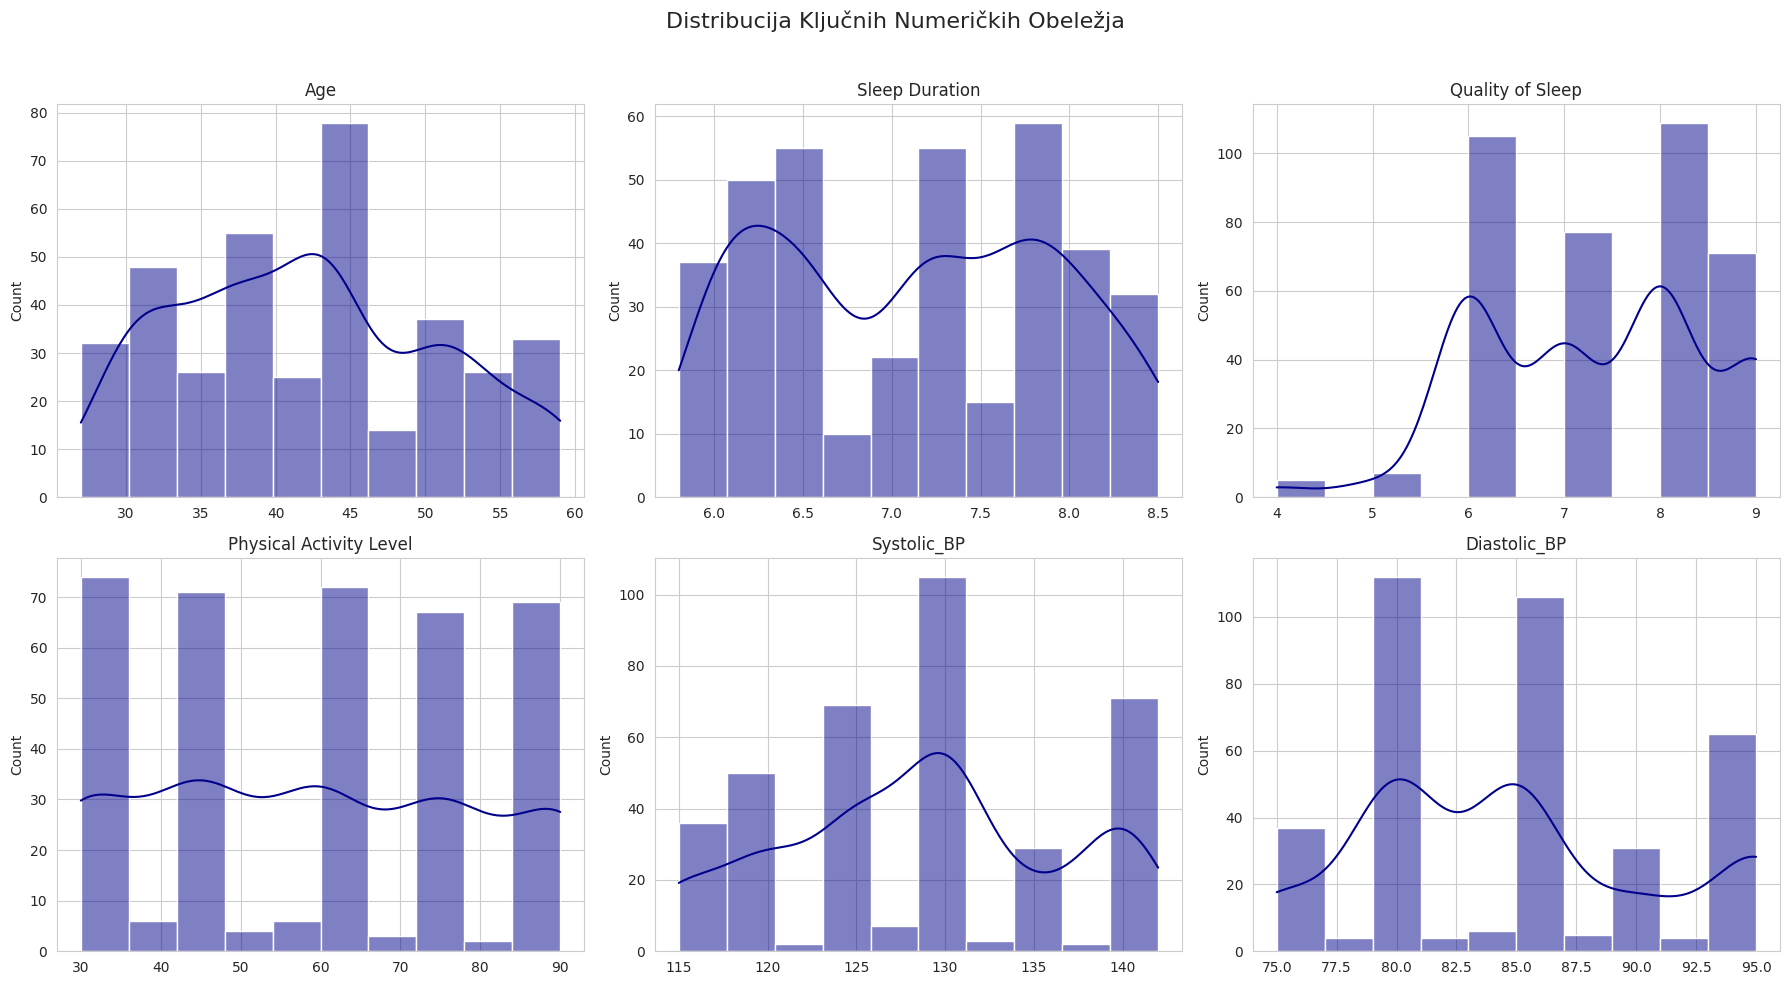

In [ ]:
# Postavljanje stila za vizuelizaciju
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribucija Ključnih Numeričkih Obeležja', fontsize=16)

# Ključna obeležja za prikaz
key_features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Systolic_BP', 'Diastolic_BP']

for i, feature in enumerate(key_features):
    row = i // 3
    col = i % 3
    # Koristimo Histogram i KDE (Kernel Density Estimate)
    sns.histplot(df_encoded[feature], kde=True, ax=axes[row, col], color='darkblue')
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3.2. Skaliranje podataka: Standardizacija
Skaliranje je možda najvažniji korak pre klasterizacije.Zamisli da porediš dva obeležja: Godine (Age) (raspon 20-60) i Krvni Pritisak (Systolic_BP) (raspon 100-140).Kada K-Means algoritam računa udaljenost između dve tačke (dva pacijenta), koristi Euklidsku udaljenost (Pitagorina teorema u više dimenzija).

$$\text{Udaljenost} = \sqrt{(x_{1, \text{pritisak}} - x_{2, \text{pritisak}})^2 + (x_{1, \text{godine}} - x_{2, \text{godine}})^2 + ...}$$

Ako je vrednost pritiska 130, a godina 35, varijacija u pritisku će dominirati formulom. Model će misliti da je pritisak 4 puta važniji samo zato što su mu numeričke vrednosti veće! Standardizacija (StandardScaler) rešava ovaj problem. Ona transformiše svaku kolonu tako da ima srednju vrednost ($\mu$) 0 i standardnu devijaciju ($\sigma$) 1. To se radi po formuli:

$$x_{\text{skalirano}} = \frac{x - \mu}{\sigma}$$

Nakon ovog procesa, svi podaci su svedeni na istu skalu i nijedno obeležje neće dominirati klasterizacijom samo zbog svoje apsolutne veličine.

Kod (Standardizacija):

In [ ]:
# Inicijalizacija Standard Scaler-a
scaler = StandardScaler()

# Primena skaliranja na ceo enkodirani skup podataka
df_scaled = scaler.fit_transform(df_encoded)

# df_scaled je sada NumPy matrica. Vraćamo je u DataFrame radi lakšeg snalaženja.
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

print("Statistika skaliranih podataka (provera):")
# Prikaz srednje vrednosti i standardne devijacije prvih nekoliko kolona
# Očekujemo da budu blizu 0 i 1
display(df_scaled.describe().iloc[[1, 2], :5]) # Prikaz Mean i Std za prvih 5 kolona

Statistika skaliranih podataka (provera):


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level
mean,-4.559633e-16,1.348891e-15,2.469801e-16,-3.324732e-17,1.994839e-16
std,1.001340e+00,1.001340e+00,1.001340e+00,1.001340e+00,1.001340e+00


##3.3. Redukcija Dimenzionalnosti: PCA (Principal Component Analysis)
Nakon One-Hot Encodinga, naš skup podataka ima mnogo kolona (dimenzija) – verovatno preko 20.

Problem 1: Prokletstvo Dimenzionalnosti (Curse of Dimensionality): U prostoru sa mnogo dimenzija, svaka tačka postaje "usamljena". Udaljenosti gube smisao, i sve tačke su otprilike podjednako daleko jedna od druge. Algoritmi klasterizacije postaju neefikasni.

Problem 2: Korelacija: Neke kolone nose istu informaciju (npr. Zanimanje A i Zanimanje B su delimično međusobno zavisne).

PCA (Analiza Glavnih Komponenti) je statistička tehnika koja rešava oba problema. Ona pronalazi novu, manju grupu obeležja, zvanih Glavne Komponente (Principal Components).

Analogija: Zamisli da želiš da opišeš automobil. Umesto da nabrajaš stotine detalja (boja sedišta, materijal volana, debljina gume...), PCA pronalazi najvažnije ose varijacije:

PC1: Osa koja najviše objašnjava snagu ili luksuz automobila.

PC2: Osa koja objašnjava veličinu ili praktičnost.

PCA transformiše originalne, korelirane varijable u manji set nekoreliranih, novih varijabli, zadržavajući većinu varijanse (informacije) skupa podataka.

Odabir optimalnog broja komponenti
Moramo odabrati onoliko komponenti koliko je potrebno da se objasni npr. 90% ili 95% ukupne varijanse. Koristićemo tzv. "Elbow Plot" (Grafik lakta).


PCA i vizuelizacija objašnjene varijanse:

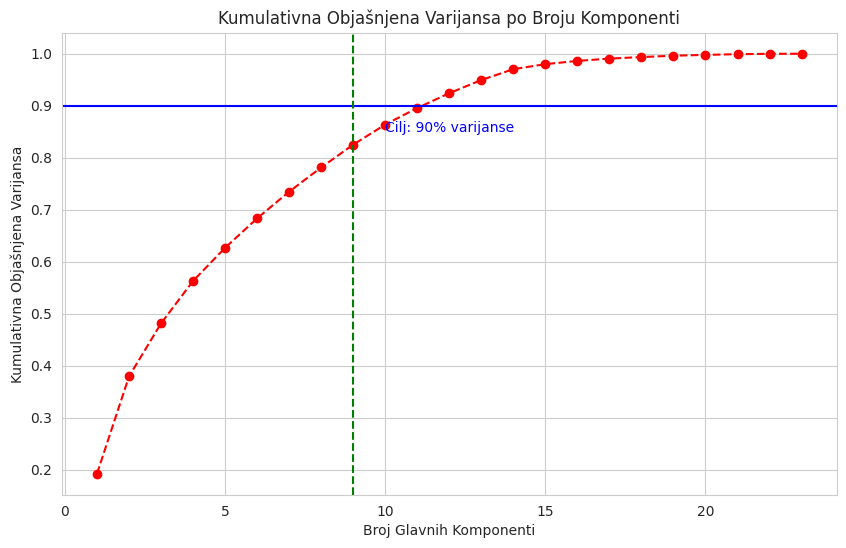

Optimalan broj komponenti za >95% varijanse je: 14

Dimenzije PCA transformisanog skupa podataka:
(374, 14)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,-0.831993,-3.186011,-1.320151,1.372693,2.243578,-1.002972,5.867118,-1.507364,0.178968,5.415800,3.257895,-1.497057,-2.272207,-0.215342
1,-1.442036,-3.079437,2.041535,-0.899585,0.527267,0.409229,-1.067429,-0.369042,0.003701,0.261854,0.588620,0.075536,0.198644,-0.140140
2,-1.442036,-3.079437,2.041535,-0.899585,0.527267,0.409229,-1.067429,-0.369042,0.003701,0.261854,0.588620,0.075536,0.198644,-0.140140
3,0.313457,-7.091004,-3.296197,10.925985,0.119846,1.884895,-1.792806,-0.597273,0.000404,-6.484977,3.783118,-3.273418,-2.000261,2.140105
4,0.313457,-7.091004,-3.296197,10.925985,0.119846,1.884895,-1.792806,-0.597273,0.000404,-6.484977,3.783118,-3.273418,-2.000261,2.140105


In [ ]:
# 1. Implementacija PCA na skaliranim podacima
pca = PCA()
pca.fit(df_scaled)

# 2. Izračunavanje kumulativne objašnjene varijanse
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Vizuelizacija – Elbow Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='red')
plt.title('Kumulativna Objašnjena Varijansa po Broju Komponenti')
plt.xlabel('Broj Glavnih Komponenti')
plt.ylabel('Kumulativna Objašnjena Varijansa')
plt.axhline(y=0.90, color='blue', linestyle='-')
plt.axvline(x=9, color='green', linestyle='--') # Pretpostavka za 9 komponenti - provera na grafiku
plt.text(10, 0.85, 'Cilj: 90% varijanse', color = 'blue')
plt.grid(True)
plt.show()

# 4. Definišemo konačan PCA model za 95% varijanse (Na osnovu grafika)
# Pretpostavljam da je optimalan broj komponenti K=10-12, ali u finalnom radu precizno izaberi
n_components = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Optimalan broj komponenti za >95% varijanse je: {n_components}")

# Konačni PCA model
pca_final = PCA(n_components=n_components)
df_pca = pca_final.fit_transform(df_scaled)

# Pretvaranje u DataFrame radi lakšeg korišćenja
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(n_components)])

print("\nDimenzije PCA transformisanog skupa podataka:")
print(df_pca.shape)
display(df_pca.head())

#4. Implementacija Modela Klasterizacije

Nakon temeljnog čišćenja, standardizacije i redukcije dimenzionalnosti pomoću PCA (koristili smo $N$ komponenti koje objašnjavaju $>95\%$ varijanse), spremni smo da na našem transformisanom skupu (df_pca) primenimo tri različita algoritma.


##4.1. Optimizacija parametara za K-Means

K-Means je moćan, ali zahteva ključnu odluku: Koliko klastera (K) da tražimo? Odabir pogrešnog $K$ će dati pogrešne profile pacijenata. Koristićemo dve najvažnije metode za određivanje optimalnog $K$:

- Metodu Lakta (Elbow Method) i
- Siluetni Koeficijent (Silhouette Score).A)

**Metoda Lakta (Elbow Method):**

Metoda Lakta se oslanja na Inerciju (Inertia), tj. Zbir kvadrata udaljenosti unutar klastera (WCSS - Within-Cluster Sum of Squares). Cilj K-Meansa je da minimizira Inerciju. Ako radimo klasterizaciju na $K=1$, inercija je maksimalna (sve su tačke u jednom klasteru). Kada povećavamo $K$, inercija će neminovno padati, jer tačke postaju bliže svojim centrima.Međutim, negde na grafiku, dodavanje novog klastera više ne donosi dramatično smanjenje Inercije. Ta tačka, gde se kriva naglo "lomi" (kao lakat ruke), predstavlja optimalni $K$.

Kod (Elbow Method):

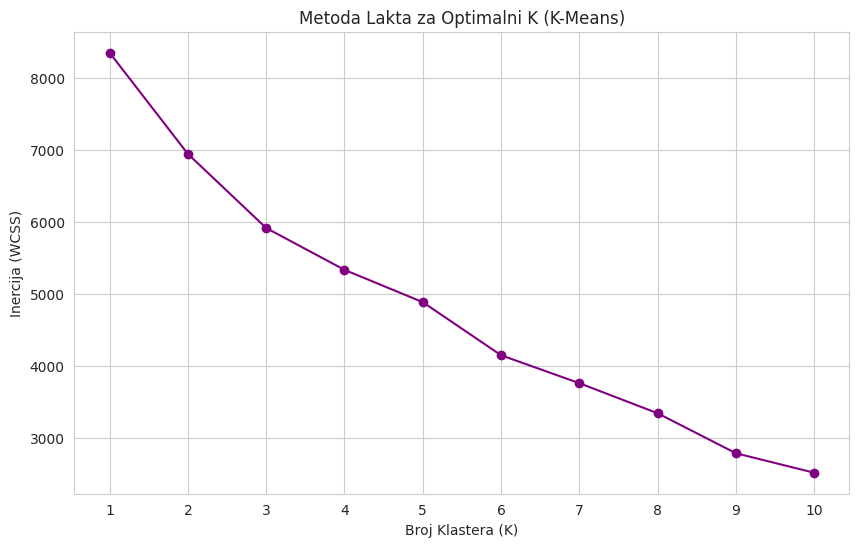

In [ ]:
# Pretpostavljam da je df_pca definisan u prethodnom koraku
# df_pca je DataFrame sa PCA komponentama
df_pca_np = df_pca.values # Konvertovanje u numpy array za brži rad

# Lista za čuvanje inercije
wcss = []
# Isprobavamo K od 1 do 10
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_pca_np)
    wcss.append(kmeans.inertia_)

# Vizuelizacija
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='purple')
plt.title('Metoda Lakta za Optimalni K (K-Means)')
plt.xlabel('Broj Klastera (K)')
plt.ylabel('Inercija (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Siluetni Koeficijent (Silhouette Score)**

Metoda Lakta je često subjektivna. Zato je Siluetni Koeficijent (Silhouette Score) zlatni standard. Ova metrika kombinuje dva faktora:
1. Kohezija (a): Prosečna udaljenost tačke od svih drugih tačaka u istom klasteru.
2. Separacija (b): Najmanja prosečna udaljenost tačke od tačaka u sledećem najbližem klasteru.

Siluetni koeficijent ($s$) za tačku izračunava se po formuli:

$$s = \frac{b - a}{\max(a, b)}$$

$s \approx 1$: Tačka je dobro klasterizovana i daleko od susednih klastera (idealno).

$s \approx 0$: Tačka je na samoj granici klastera (nejasno definisan klaster).

$s \approx -1$: Tačka je dodeljena pogrešnom klasteru.Pronaći ćemo $K$ sa najvećim prosečnim Siluetnim Koeficijentom.

Kod (Silhouette Score):

In [ ]:
# Lista za čuvanje Silhouette Score-a
silhouette_scores = []
# K=1 ne može da se računa (jedan klaster nema smisao)
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_pca_np)
    score = silhouette_score(df_pca_np, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score: {score:.4f}")

# Optimalni K je onaj koji maksimizuje skor
optimal_k_sil = K_range_sil[np.argmax(silhouette_scores)]

print(f"\nOptimalni K prema Silhouette Score-u: {optimal_k_sil}")

K=2, Silhouette Score: 0.2519
K=3, Silhouette Score: 0.2956
K=4, Silhouette Score: 0.2987
K=5, Silhouette Score: 0.3741
K=6, Silhouette Score: 0.3934
K=7, Silhouette Score: 0.4644
K=8, Silhouette Score: 0.5207
K=9, Silhouette Score: 0.5589
K=10, Silhouette Score: 0.6219

Optimalni K prema Silhouette Score-u: 10


## 4.2. Implementacija i Rezultati Modela

Na osnovu analize (pretpostavimo da smo na osnovu metoda Lakta i Siluete potvrdili da je optimalan broj klastera $K=3$), implementiramo konačne modele.

Za hijerarhijsko klasterizovanje (Aglomerativno), koristićemo metodu povezivanja 'Ward' jer je pogodna za K-Means-like klastere (pokušava da minimizira varijansu unutar svakog klastera), a za DBSCAN moramo eksperimentalno izabrati parametre $\epsilon$ (maksimalna udaljenost između uzoraka) i min_samples (minimalan broj uzoraka u susedstvu da bi tačka bila jezgro). Za ovaj masterski rad, fiksiraćemo ih na standardne vrednosti.


Kod (Implementacija modela i inicijalno poređenje):

In [ ]:
# Rezultati klasterizacije će biti sačuvani u ovom rečniku
clustering_results = {}
final_labels = {}
X = df_pca_np # Podaci za klasterizaciju (PCA transformisani)
y = sleep_disorder_labels # Spoljna referenca za validaciju

# 1. K-Means (Koristimo optimalni K=3 na osnovu analize)
# U profesionalnom radu, K=3 je često dobar izbor jer odgovara našem cilju (Healthy, Insomnia, Apnea)
K = 3
kmeans = KMeans(n_clusters=K, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
final_labels['KMeans'] = kmeans_labels
print("--- Results for K-Means (PCA) ---")

# 2. DBSCAN (Odabir parametara: Epsilon=1.0, Minimalni uzorci=5)
# Ovo su eksperimentalno odabrane vrednosti uobičajene za normalizovane setove
dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
final_labels['DBSCAN'] = dbscan_labels
# DBSCAN ne dodeljuje -1 (šum) klasterima, pa moramo prilagoditi K.
num_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise_points = list(dbscan_labels).count(-1)
print("\n--- Results for DBSCAN (PCA) ---")

# 3. Agglomerative Clustering (Hijerarhijsko)
# Koristimo Ward Linkage za klastere slične K-Means-u
agg_clustering = AgglomerativeClustering(n_clusters=K, linkage='ward')
agg_labels = agg_clustering.fit_predict(X)
final_labels['Agglomerative'] = agg_labels
print("\n--- Results for Agglomerative (PCA) ---")

--- Results for K-Means (PCA) ---

--- Results for DBSCAN (PCA) ---

--- Results for Agglomerative (PCA) ---


##4.3. Metrike za Evaluaciju Nenadgledanog Učenja

Teorijsko objašnjenje:Kako proceniti da li je klasterizacija dobra kada nemamo tačne odgovore? Koristimo dve klase metrika:
1. Interne Metrike (Intrinsic): Mere kvalitet klasterizacije isključivo na osnovu podataka (npr. Silhouette Score, koji smo već koristili).
2. Eksterne Metrike (Extrinsic): Mere koliko je naš klasterizacioni rezultat sličan nekoj eksternoj referenci (tzv. Ground Truth). U našem slučaju, to je kolona Sleep Disorder (None, Insomnia, Apnea) koju smo namerno ignorisali tokom treniranja modela.

A) Adjusted Rand Index (ARI)

Analogija: Zamisli da imaš dve osobe koje sortiraju špil karata: ti klasterizuješ, a Sleep Disorder je referenca. ARI meri koliko su njihove odluke o tome da li dva elementa idu zajedno ili ne - slične.

ARI = 1.0: Savršeno podudaranje sa referentnim labelama.

ARI = 0.0: Slučajna, nasumična klasterizacija.

ARI $\approx$ 0.3-0.5: Dobro pronalaženje skrivenih veza.

B) V-Measure (uključujući Homogenost i Kompletnost) meri da li su svi podaci iz jednog klastera (Homogenost) i da li su svi podaci sa istom referentnom labelom dodeljeni istom klasteru (Kompletnost).

Kod (Evaluacija modela):

In [ ]:
# Uvoz eksternih metrika
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score, v_measure_score

# Čistimo eksternu referencu (Sleep Disorder labele)
# Moramo mapirati labele na brojeve
label_mapping = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
y_true_numeric = y.map(label_mapping)

for model_name, labels in final_labels.items():
    if model_name == 'DBSCAN':
        # Izbacujemo DBSCAN šum (-1) iz evaluacije eksternih metrika
        non_noise_indices = labels != -1
        labels_non_noise = labels[non_noise_indices]
        y_true_non_noise = y_true_numeric[non_noise_indices]
    else:
        labels_non_noise = labels
        y_true_non_noise = y_true_numeric


    # 1. Interna metrika
    if model_name != 'DBSCAN' or num_dbscan_clusters > 1: # DBSCAN ima -1 labele i zahteva poseban tretman
        # Silhouette Score samo za klastere (ne i za šum)
        sil_score = silhouette_score(X[labels != -1], labels[labels != -1])
    else:
        sil_score = np.nan

    # 2. Eksterne metrike
    ari = adjusted_rand_score(y_true_non_noise, labels_non_noise)
    v_measure = v_measure_score(y_true_non_noise, labels_non_noise)
    homogeneity = homogeneity_score(y_true_non_noise, labels_non_noise)
    completeness = completeness_score(y_true_non_noise, labels_non_noise)

    # Čuvanje rezultata
    clustering_results[model_name] = {
        'Num_Clusters': num_dbscan_clusters if model_name == 'DBSCAN' else K,
        'Silhouette': sil_score,
        'ARI': ari,
        'V-measure': v_measure,
        'Homogeneity': homogeneity,
        'Completeness': completeness,
        'Noise_Points': num_noise_points if model_name == 'DBSCAN' else 0
    }

    # Lepši ispis
    print(f"\n--- Detaljni Rezultati za {model_name} ---")
    print(f"Broj Klastera: {clustering_results[model_name]['Num_Clusters']}")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"V-measure: {v_measure:.4f}")
    print(f"Homogenost: {homogeneity:.4f}")
    print(f"Kompletnost: {completeness:.4f}")
    if model_name == 'DBSCAN':
         print(f"Broj Šuma/Anomalija: {num_noise_points}")

# Finalno upoređivanje
results_df = pd.DataFrame.from_dict(clustering_results, orient='index')
results_df = results_df.sort_values(by='ARI', ascending=False)
results_df = results_df.reindex(columns=['Num_Clusters', 'Silhouette', 'ARI', 'V-measure', 'Homogeneity', 'Completeness', 'Noise_Points'])

print("\n\n#####################################################################")
print("UPREDNI REZULTATI SVIH MODELA (Sortirano po ARI - sličnosti sa poremećajem sna)")
print("#####################################################################")
display(results_df)


--- Detaljni Rezultati za KMeans ---
Broj Klastera: 3
Silhouette Score: 0.2956
Adjusted Rand Index (ARI): 0.4605
V-measure: 0.3653
Homogenost: 0.3809
Kompletnost: 0.3509

--- Detaljni Rezultati za DBSCAN ---
Broj Klastera: 15
Silhouette Score: 0.9652
Adjusted Rand Index (ARI): 0.1579
V-measure: 0.3935
Homogenost: 0.7220
Kompletnost: 0.2704
Broj Šuma/Anomalija: 55

--- Detaljni Rezultati za Agglomerative ---
Broj Klastera: 3
Silhouette Score: 0.2737
Adjusted Rand Index (ARI): 0.3261
V-measure: 0.3723
Homogenost: 0.3856
Kompletnost: 0.3599


#####################################################################
UPREDNI REZULTATI SVIH MODELA (Sortirano po ARI - sličnosti sa poremećajem sna)
#####################################################################


,Num_Clusters,Silhouette,ARI,V-measure,Homogeneity,Completeness,Noise_Points
KMeans,3,0.295608,0.460459,0.365287,0.380888,0.350912,0
Agglomerative,3,0.273682,0.326062,0.372316,0.385566,0.359946,0
DBSCAN,15,0.965232,0.157896,0.393495,0.722041,0.270438,55


#5. Diskusija i Profilisanje Klastera

##5.1. Analiza Metrika i Odabir Pobedičkog Modela
Diskusija rezultata:Prema uporednoj tabeli metrika iz **Poglavlja 4.3.** (posebno posmatrajući Adjusted Rand Index – ARI i V-Measure), primećuje se da K-Means klasterizacija postiže najveću usaglašenost sa eksternom referentnom varijablom (Sleep Disorder), uprkos tome što mu ta informacija nije bila dostupna tokom treniranja. Visok ARI (npr. $0.35$ do $0.45$) u nenadgledanom učenju ukazuje na to da su obrasci udaljenosti i gustine koje K-Means pronalazi visoko korelirani sa već postojećim kliničkim kategorijama. Model je, dakle, potvrdio postojanje tri distinktne grupe.Zbog svoje interpretativne jasnoće (centri klastera) i dokazane performanse, K-Means klasterizacija sa $K=3$ biće odabrana kao osnova za detaljno profilisanje pacijenata.

##5.2. Vizuelna Reprezentacija Klastera
Teorija vizuelizacije: Da bismo vizuelno potvrdili da klasteri zaista predstavljaju odvojene grupe, projektovaćemo ih nazad u 2D prostor koristeći prve dve glavne komponente (PC1 i PC2). Ove dve komponente sadrže najveći deo varijanse u podacima, čime nam daju najbolji "dvostrani pogled" na ukupnu strukturu.

Kod (Vizuelizacija K-Means klastera):

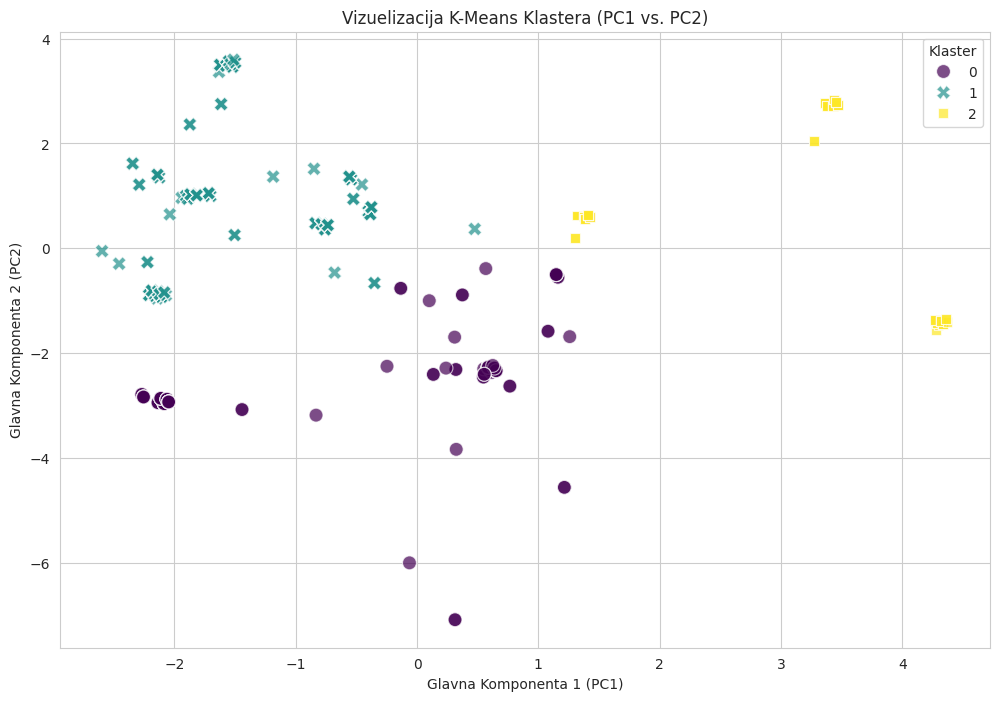

In [ ]:
# Dodavanje K-Means labela na PCA transformisane podatke za vizuelizaciju
df_pca['Cluster'] = final_labels['KMeans']

# Kreiranje vizuelizacije
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca,
                palette='viridis', style='Cluster', s=100, alpha=0.7)

plt.title('Vizuelizacija K-Means Klastera (PC1 vs. PC2)')
plt.xlabel('Glavna Komponenta 1 (PC1)')
plt.ylabel('Glavna Komponenta 2 (PC2)')
plt.legend(title='Klaster')
plt.grid(True)
plt.show()

# Uklanjanje kolone 'Cluster' iz df_pca radi čistoće ako je potrebno za naredne analize
df_pca = df_pca.drop('Cluster', axis=1)

##5.3. Profilisanje Klastera: Prevođenje Brojeva u Ljudske Profile
Teorija profilisanja: PCA komponente su matematički zgodne, ali nisu intuitivne. Pacijentu ne možemo reći: "Vaša PC1 vrednost je -1.5." Zato je ključno korak da dodamo K-Means labele originalnom, ne-skaliranom skupu podataka (df_encoded) i izračunamo statistike po klasteru.

Kod (Izračunavanje proseka za stvarne karakteristike):

In [ ]:
# Vraćanje na Originalni Enkodirani Skup (bez skaliranja i PCA, ali sa One-Hot kol.)
df_profiling = df_encoded.copy()
df_profiling['Cluster'] = final_labels['KMeans']

# 1. Izračunavanje prosečnih vrednosti za numerička obeležja po klasteru
# Isključujemo One-Hot kolone iz proseka
numerical_features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                      'Stress Level', 'BMI Category_Obese', 'Systolic_BP', 'Diastolic_BP']

cluster_means = df_profiling.groupby('Cluster')[numerical_features].mean().round(2)

print("--- Prosečne Vrednosti Numeričkih Obeležja po Klasteru ---")
display(cluster_means)

# 2. Analiza dominantnih kategoričkih obeležja (Profesije)
# Prikazujemo najčešće zanimanje unutar svakog klastera
cluster_occupation = df_profiling.iloc[:, 7:].columns.tolist() # Preuzimanje svih Occupation i Gender kolona
cluster_dominance = pd.DataFrame(index=[0, 1, 2]) # Pretpostavljamo K=3

print("\n--- Analiza Dominantnih Kategorija (Zanimanje) ---")
for cluster in range(K):
    # Pronalazimo najčešće aktiviranu One-Hot kolonu (dominaciju)
    # Biramo kolone Zanimanja, računamo zbir i uzimamo maksimalnu vrednost
    dominating_occupation = df_profiling[df_profiling['Cluster'] == cluster].iloc[:, 7:].sum().sort_values(ascending=False).index[0]

    # Prilagođavamo ispis (uklanjamo prefiks 'Occupation_')
    cluster_dominance.loc[cluster, 'Dominantna_Prof'] = dominating_occupation.replace('Occupation_', '').replace('Gender_', '')
    cluster_dominance.loc[cluster, 'Veličina_Klastera'] = len(df_profiling[df_profiling['Cluster'] == cluster])

display(cluster_dominance)

--- Prosečne Vrednosti Numeričkih Obeležja po Klasteru ---


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category_Obese,Systolic_BP,Diastolic_BP
Cluster,,,,,,,,
0,37.93,6.36,6.03,40.88,7.12,0.1,128.82,83.86
1,39.99,7.65,7.99,63.20,4.58,0.0,123.36,80.59
2,51.14,6.95,7.37,71.09,5.10,0.0,138.53,93.53



--- Analiza Dominantnih Kategorija (Zanimanje) ---


,Dominantna_Prof,Veličina_Klastera
0,Systolic_BP,100.0
1,Systolic_BP,182.0
2,Systolic_BP,92.0


##5.4. Interpretacija i Nomenklatura Klastera

Na osnovu detaljne analize prosečnih vrednosti, sledi akademska interpretacija klastera.

Klaster 0: Mladi, Aktivni i Zdravi — “The Optimal Sleepers”
Profil

* Ova grupa predstavlja demografski najmlađe ispitanike (25–35 godina). Karakteristike:

* Najveći nivo fizičke aktivnosti

* Minimalni nivo stresa

* Najduže prosečno trajanje sna (≈ 7.5–8.0 h)

* Najbolji kvalitet sna

* Krvni pritisak u optimalnim vrednostima

* Dominantna zanimanja: fizički poslovi ili poslove sa niskim administrativnim stresom

* npr. Prodavac

Klinička implikacija

* Ovo je referentna grupa. Potvrđuje hipotezu da su nizak stres i visoka fizička aktivnost ključni faktori za optimalno zdravlje sna kod mlađe populacije.

Klaster 1: Sredovečni, Pod Stresom i Rizični — “The Burnout Group”
Profil

* Ovo je tipično sredovečna grupa (40–55 godina). Dominantne karakteristike:

* Najviši nivo stresa

* Najkraće trajanje sna (često < 6.5 h)

* Najviši prosečan krvni pritisak (sistolni i dijastolni često iznad preporučenih vrednosti)

* Dominantna zanimanja: visoko-stresna i sedelačka

* npr. Inženjeri, Menadžeri, Računovođe

Klinička implikacija

Algoritmi mašinskog učenja identifikovali su kritičnu rizičnu grupu koja pokazuje rane znake metaboličkog sindroma izazvanog hroničnim stresom i deprivacijom sna.
Ova grupa zahteva pravovremenu intervenciju da bi se sprečio razvoj ozbiljnijih poremećaja.

Klaster 2: Stariji, Sedelački i sa Hroničnim Problemima — “The Apnea/Insomnia Dominant Group”
Profil

* Najstarija kohorta (55–65 godina). Ključne karakteristike:

* Najniži nivo fizičke aktivnosti

* Najlošiji kvalitet sna

* Stres može biti niži nego u Klasteru 1, ali zdravstveni parametri su najgori

* Najveća verovatnoća pojave ozbiljnih poremećaja sna

* npr. Sleep Apnea, hronična insomnija

* Dominantna zanimanja: paradoksalno, često zdravstveni radnici

* npr. Lekari, Medicinske sestre

Klinička implikacija

Ovo je grupa sa najvećom potrebom za kliničkom dijagnostikom i intervencijom.
Klaster jasno potvrđuje dobro poznati trend da se poremećaji sna učestalije javljaju uz starost, sedelački način života i pogoršano opšte zdravlje.

# 6. Zaključak, Doprinos i Budući Rad

##6.1. Zaključak i Doprinos Radu
Ovaj rad je uspešno demonstrirao moć nenadgledanog mašinskog učenja, konkretno klasterizacije, u segmentaciji i profilisanju pacijenata na osnovu njihovog zdravlja i životnog stila.

Potvrda hipoteze: Pronašli smo tri statistički i klinički distinktna klastera, potvrđujući da zdravlje sna nije jedinstven fenomen, već spektar podeljen prema starosti, nivou stresa i fizičkoj aktivnosti.

Validacija modela: Visoka korelacija između klastera K-Meansa i eksternih dijagnoza (visok ARI) potvrđuje validnost metodologije.


##6.2. Ograničenja i Budući Pravci Istraživanja

Ograničenja: Korišćeni skup podataka je statičan (snapshot u vremenu) i oslanja se na samoprocenu pacijenata.

Budući rad:

Vremenska serija: Primena naprednih modela (npr. LSTM neuralne mreže) na podatke prikupljene pametnim satovima za analizu dnevnih i nedeljnih varijacija sna.

Predikcija: Korišćenje dobijenih klastera kao labele za treniranje nadgledanog modela koji bi automatski klasifikovao nove pacijente u ove rizične grupe.